# Synthetic event-time regression discontinuity

This example illustrates an immediate onset effect among eventual users. Every observation is generated here; no external data are read. The construction is a statistical teaching example, with no claim of biological realism or reproduction of manuscript results.

Let $X$ denote continuous event time centered at onset, and let $D=1[X>0]$. Draw an independent baseline covariate $Z$, a three-level category, and noise $\epsilon$. Set
$$
Y(0)=1+0.7X+0.5Z+\epsilon,\qquad Y(1)=Y(0)-2,
$$
then observe $Y=Y(0)-2D$. Continuity is built into the potential-outcome means. The true cutoff local average treatment effect among the treated (LATT), interpreted here as the immediate onset effect among eventual users, is $-2$.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from event_time_rd import estimate_rd, covariate_balance

SEED = 20260926
N = 4000
TRUE_LATT = -2.0


In [2]:
rng = np.random.default_rng(SEED)
event_time = rng.uniform(-1, 1, N)
baseline = rng.normal(size=N)
category = rng.choice(["A", "B", "C"], size=N)
noise = rng.normal(size=N)
treatment = (event_time > 0).astype(int)
y0 = 1 + 0.7 * event_time + 0.5 * baseline + noise
y1 = y0 + TRUE_LATT

df = pd.DataFrame({
    "event_time": event_time,
    "baseline": baseline,
    "category": category,
    "treatment": treatment,
    "outcome": y0 + TRUE_LATT * treatment,
})

# Check the stated construction, without requiring a particular inference result.
assert np.allclose(y1 - y0, TRUE_LATT)
assert np.allclose(df["outcome"], np.where(treatment == 1, y1, y0))
display(df.head())

,event_time,baseline,category,treatment,outcome
0,0.675173,-0.856440,A,1,0.372231
1,0.651431,1.431559,A,1,-0.223555
2,0.219372,0.216687,C,1,-2.035969
3,0.584620,0.479445,C,1,0.604792
4,0.943224,0.315981,C,1,-0.410711


## Estimate the cutoff effect

Fit an unadjusted RD and an RD adjusted for the numeric baseline covariate. Both use the library's default data-driven bandwidth selection. The distribution diagnostics below use the full generated analysis sample; they do not determine these estimation bandwidths.

In [3]:
fits = {
    "Unadjusted": estimate_rd(df["outcome"], df["event_time"]),
    "Adjusted for baseline": estimate_rd(
        df["outcome"], df["event_time"], covariates=df[["baseline"]]
    ),
}
results = pd.DataFrame.from_dict(fits, orient="index")

The first table reports conventional estimates and inference. The second reports bias-corrected estimates with robust bias-corrected (RBC) 95% confidence intervals and p-values for a zero cutoff effect. These estimates and standard errors are kept separate. Sampling variation means a confidence interval need not contain the known truth in this particular sample.

In [4]:
print(f"Known cutoff effect: {TRUE_LATT:g}")
print("Conventional estimate and inference")
display(results[["estimate", "se", "ci_low", "ci_high", "p_value"]])

print("Bias-corrected estimate and robust bias-corrected inference")
display(results[[
    "estimate_bias_corrected", "se_robust", "ci_robust_low",
    "ci_robust_high", "p_value_robust",
]])

print("Sample sizes and selected bandwidths")
display(results[[
    "n_input", "n_used", "n_excluded", "n_effective_left", "n_effective_right",
    "bandwidth_left", "bandwidth_right", "bias_bandwidth_left", "bias_bandwidth_right",
]])

Known cutoff effect: -2
Conventional estimate and inference


,estimate,se,ci_low,ci_high,p_value
Unadjusted,-1.906752,0.146518,-2.193921,-1.619583,1.021314e-38
Adjusted for baseline,-1.922621,0.127738,-2.172983,-1.672260,3.384190e-51


Bias-corrected estimate and robust bias-corrected inference


,estimate_bias_corrected,se_robust,ci_robust_low,ci_robust_high,p_value_robust
Unadjusted,-1.898723,0.176126,-2.243924,-1.553522,4.257343e-27
Adjusted for baseline,-1.907953,0.153750,-2.209297,-1.606608,2.322378e-35


Sample sizes and selected bandwidths


,n_input,n_used,n_excluded,n_effective_left,n_effective_right,bandwidth_left,bandwidth_right,bias_bandwidth_left,bias_bandwidth_right
Unadjusted,4000,4000,0,536,564,0.273023,0.273023,0.413139,0.413139
Adjusted for baseline,4000,4000,0,624,668,0.313460,0.313460,0.470222,0.470222


## Visualize the synthetic sample

The points and bin averages summarize the simulated observations. The orange segments are the **known conditional means**, $E[Y\mid X]=1+0.7X-2\,1[X>0]$, after averaging over the independent baseline and noise. They are not fitted regression lines.

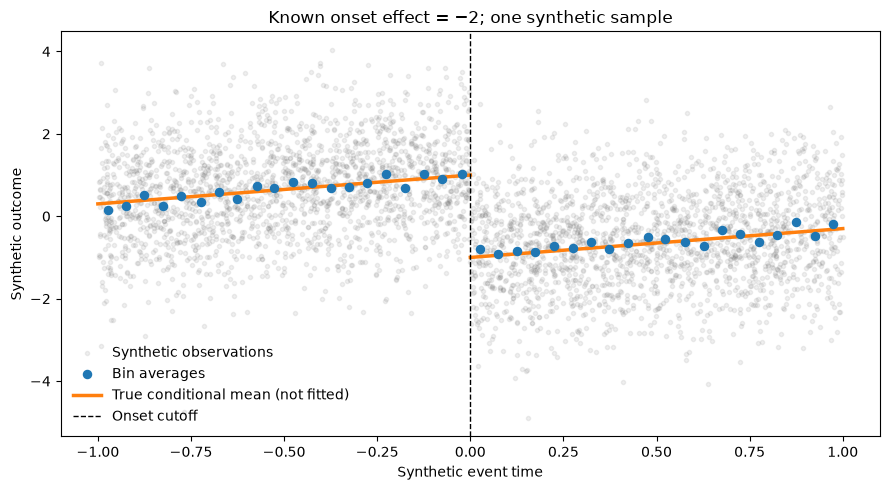

In [5]:
plot_data = df.assign(bin=pd.cut(df["event_time"], np.linspace(-1, 1, 41)))
binned = plot_data.groupby("bin", observed=True)[["event_time", "outcome"]].mean()

fig, ax = plt.subplots(figsize=(9, 5))
ax.scatter(df["event_time"], df["outcome"], s=9, color="0.4", alpha=0.10,
           label="Synthetic observations", rasterized=True)
ax.scatter(binned["event_time"], binned["outcome"], s=34, color="tab:blue",
           label="Bin averages", zorder=3)
left = np.linspace(-1, 0, 100)
right = np.linspace(0, 1, 100)
ax.plot(left, 1 + 0.7 * left, color="tab:orange", lw=2.5,
        label="True conditional mean (not fitted)")
ax.plot(right, 1 + 0.7 * right + TRUE_LATT, color="tab:orange", lw=2.5)
ax.axvline(0, color="black", ls="--", lw=1, label="Onset cutoff")
ax.set(xlabel="Synthetic event time", ylabel="Synthetic outcome",
       title="Known onset effect = −2; one synthetic sample")
ax.legend(frameon=False)
fig.tight_layout()
plt.show()

## Covariate distribution diagnostics

Compare the two sides of the full generated analysis sample, excluding event time zero. As in the article, the library uses the two-sample K–S statistic with its limiting Kolmogorov P value for numeric continuous or ordered covariates, and Pearson's chi-squared test for categorical covariates (Yates correction for 2×2 tables). These assess distributional differences, not just differences in means. The baseline and category were generated independently of event time; chance imbalances can still occur.

In [6]:
balance = covariate_balance(
    df["event_time"],
    df[["baseline", "category"]],
    categorical=["category"],
)
display(balance)

,covariate,type,n_left,n_right,statistic,p_value,status
0,baseline,continuous,2008,1992,0.028350,0.397563,ok
1,category,categorical,2008,1992,0.081319,0.960156,ok


Non-rejection is not proof of identification or continuity. These diagnostics compare distributions across a finite window; a window-wide difference is not itself a discontinuity at zero. Conversely, a small p-value can arise by chance. Identification in this example follows from the constructed potential outcomes and independence assumptions, not from passing the diagnostics.